# **MLIS Practical 10**

**Name:** Yesha Pandya  
**Enrollment No:** 23BT04175  
**Division:** A
**Batch**: C

## **Objective**
To perform sentiment analysis on Amazon Fine Food Reviews using a machine learning model.

## **Theoretical Overview**
Sentiment analysis automates the extraction of subjective opinion and emotional polarity from customer reviews. Raw text cannot be processed directly by numerical ML algorithms and must be transformed into a high-dimensional vector space using Term Frequency-Inverse Document Frequency (TF-IDF).

## **Mathematical Formulation**

#### **1. Term Frequency-Inverse Document Frequency (TF-IDF):**
* **Term Frequency ($TF$)**: Measures the relative occurrence of term $t$ in review document $d$:
$$TF(t, d) = \frac{f_{t, d}}{\sum_{t' \in d} f_{t', d}}$$
* **Inverse Document Frequency ($IDF$)**: Penalizes generic words occurring across all $N$ review documents:
$$IDF(t, D) = \log\left(\frac{1 + N}{1 + \vert{}\{d \in D : t \in d\}\vert{}}\right) + 1$$
* **Composite TF-IDF Weight:**
$$\text{TF-IDF}(t, d, D) = TF(t, d) \times IDF(t, D)$$
#### **2. Logistic Regression Classifier:**
Calculates log-odds probability score $z$ for review feature vector $\mathbf{x}$:
$$z = \mathbf{w}^T \mathbf{x} + b$$$$\hat{y} = P(y = 1 \mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

#### **3. Objective Loss Function (L2-Regularized Binary Cross-Entropy):**
$$\mathcal{L}(\mathbf{w}, b) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right] + \frac{\lambda}{2} \Vert{}\mathbf{w}\Vert{}^2_2$$

## **Step 1: Setup + Load dataset**

In [2]:
# Install kagglehub to download Amazon Fine Food Reviews dataset directly in Google Colab
!pip install kagglehub -q

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

import kagglehub

# Download Amazon Fine Food Reviews dataset
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
print("Dataset downloaded to folder:", path)

# Load a subset for optimal memory and fast execution
csv_file_path = os.path.join(path, "Reviews.csv")
df_raw = pd.read_csv(csv_file_path, nrows=30000)

print(f"Raw Dataset Shape: {df_raw.shape}")
print("\nFirst 3 Sample Reviews:")
display(df_raw[['Score', 'Summary', 'Text']].head(3))

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
Dataset downloaded to folder: /kaggle/input/amazon-fine-food-reviews
Raw Dataset Shape: (30000, 10)

First 3 Sample Reviews:


,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...


## **Step 2: Text Preprocessing + Target Binary Encoding**
To convert raw unformatted customer reviews into structured NLP inputs:

* **Neutral Review Exclusion**: Ratings equal to 3 are removed to create strict binary sentiment boundaries.

* **Binary Label Mapping**:
  * Ratings 4–5 are assigned `1` (Positive)
  * Ratings 1–2 are assigned `0` (Negative).

* **Regex Noise Cleaning**: Stripping HTML tags (`<br/>`), special characters, and numbers.

* **Stopword Filtering**: Eliminating non-informative standard English stopwords using NLTK.

In [3]:
# 1. Drop neutral reviews (Score = 3)
df_filtered = df_raw[df_raw['Score'] != 3].copy()

# 2. Assign Binary Labels: 1 for Positive (>3), 0 for Negative (<3)
df_filtered['Sentiment'] = df_filtered['Score'].apply(lambda x: 1 if x > 3 else 0)

# Drop missing text rows
df_filtered = df_filtered.dropna(subset=['Text']).reset_index(drop=True)

# 3. Define text cleaning function
stop_words = set(stopwords.words('english'))

def clean_review_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)             # Keep alphabets only
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(cleaned_words)

# Apply preprocessing
df_filtered['Cleaned_Text'] = df_filtered['Text'].apply(clean_review_text)

print(f"Filtered Dataset Shape: {df_filtered.shape}")
print(f"Positive Reviews: {sum(df_filtered['Sentiment'] == 1):,}")
print(f"Negative Reviews: {sum(df_filtered['Sentiment'] == 0):,}")

Filtered Dataset Shape: (27507, 12)
Positive Reviews: 23,068
Negative Reviews: 4,439


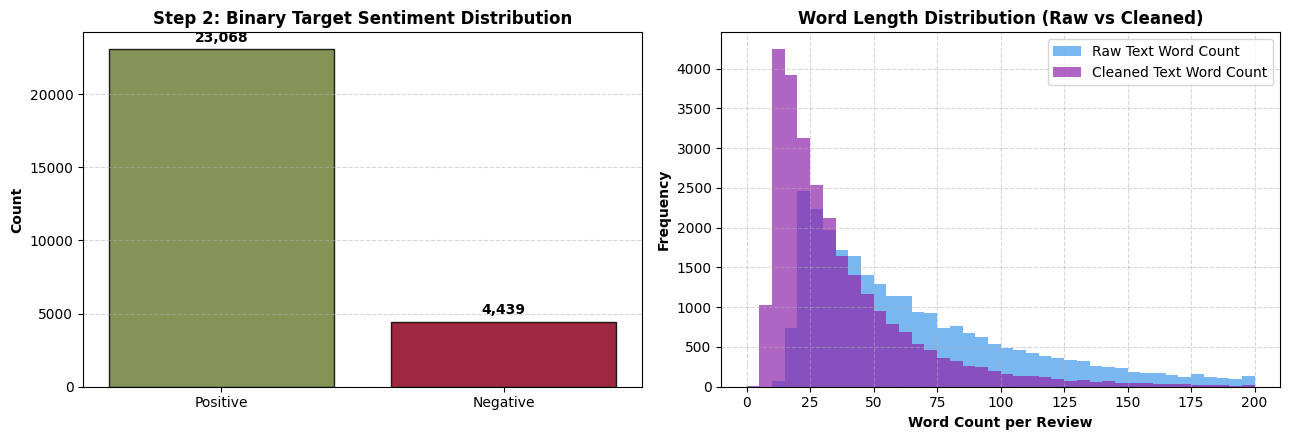

In [4]:
# Visualize Binary Class Distribution + Word Length Comparison
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot 1: Binary Sentiment Target Balance
sentiment_counts = df_filtered['Sentiment'].map({1: 'Positive', 0: 'Negative'}).value_counts()
bars = ax[0].bar(sentiment_counts.index, sentiment_counts.values, color=['#708238', '#8D021F'], edgecolor='black', alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2.0, yval + 300, f"{yval:,}", ha='center', va='bottom', fontweight='bold')

ax[0].set_title("Step 2: Binary Target Sentiment Distribution", fontsize=12, fontweight='bold')
ax[0].set_ylabel("Count", fontweight='bold')
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: Review Word Length Distribution Before vs After Cleaning
raw_lengths = df_filtered['Text'].apply(lambda x: len(str(x).split()))
clean_lengths = df_filtered['Cleaned_Text'].apply(lambda x: len(x.split()))

ax[1].hist(raw_lengths, bins=40, range=(0, 200), color='#1E88E5', alpha=0.6, label='Raw Text Word Count')
ax[1].hist(clean_lengths, bins=40, range=(0, 200), color='#8E24AA', alpha=0.7, label='Cleaned Text Word Count')
ax[1].set_title("Word Length Distribution (Raw vs Cleaned)", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Word Count per Review", fontweight='bold')
ax[1].set_ylabel("Frequency", fontweight='bold')
ax[1].legend(frameon=True)
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## **Step 3: Dataset Splitting + TF-IDF Feature Extraction**
Partition the cleaned corpus into 80-20 train-test sets using stratified sampling; followed by TF-IDF vectorization with a maximum of 5,000 top n-gram features.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df_filtered['Cleaned_Text']
y = df_filtered['Sentiment']

# Split dataset into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Extract TF-IDF features (top 5,000 unigrams and bigrams)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"X_train TF-IDF Matrix Shape: {X_train_tfidf.shape}")
print(f"X_test TF-IDF Matrix Shape:  {X_test_tfidf.shape}")

X_train TF-IDF Matrix Shape: (22005, 5000)
X_test TF-IDF Matrix Shape:  (5502, 5000)


## **Step 4: Machine Learning Model Training**
We train an L2-regularized Logistic Regression classifier on the 5000-dimensional TF-IDF feature space and analyze the learned model coefficients for positive v/s negative sentiment indicators.

Logistic Regression Model Training Complete!


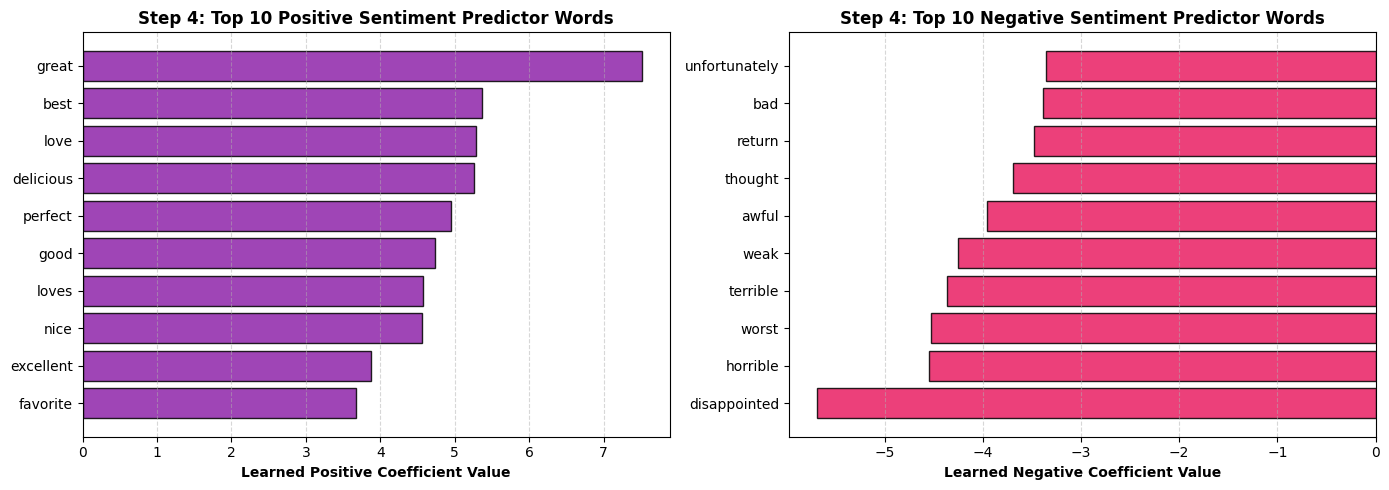

In [6]:
from sklearn.linear_model import LogisticRegression

# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
model.fit(X_train_tfidf, y_train)

print("Logistic Regression Model Training Complete!")

# Extract top positive and negative feature coefficients
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = model.coef_.ravel()

top_pos_idx = np.argsort(coefficients)[-10:]
top_neg_idx = np.argsort(coefficients)[:10]

pos_words, pos_coeffs = feature_names[top_pos_idx], coefficients[top_pos_idx]
neg_words, neg_coeffs = feature_names[top_neg_idx], coefficients[top_neg_idx]

# (Visualize) Top Positive vs Negative Model Coefficients
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Top Positive Predictors
ax[0].barh(pos_words, pos_coeffs, color='#8E24AA', edgecolor='black', alpha=0.85)
ax[0].set_title("Step 4: Top 10 Positive Sentiment Predictor Words", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Learned Positive Coefficient Value", fontweight='bold')
ax[0].grid(axis='x', linestyle='--', alpha=0.5)

# Top Negative Predictors
ax[1].barh(neg_words, neg_coeffs, color='#E91E63', edgecolor='black', alpha=0.85)
ax[1].set_title("Step 4: Top 10 Negative Sentiment Predictor Words", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Learned Negative Coefficient Value", fontweight='bold')
ax[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## **Step 5: Testing + Evaluation Metrics**
We evaluate the sentiment classifier on the unseen test dataset across standard metrics: Accuracy, Precision, Recall, and F1-Score.

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predict on unseen test set
y_pred = model.predict(X_test_tfidf)
y_pred_probs = model.predict_proba(X_test_tfidf)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("Sentiment Analysis Evaluation Metrics:")
print(f"Accuracy  : {acc * 100:.2f}%")
print(f"Precision : {prec * 100:.2f}%")
print(f"Recall    : {rec * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Sentiment Analysis Evaluation Metrics:
Accuracy  : 91.00%
Precision : 91.23%
Recall    : 98.76%
F1-Score  : 94.85%

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.51      0.65       888
    Positive       0.91      0.99      0.95      4614

    accuracy                           0.91      5502
   macro avg       0.90      0.75      0.80      5502
weighted avg       0.91      0.91      0.90      5502



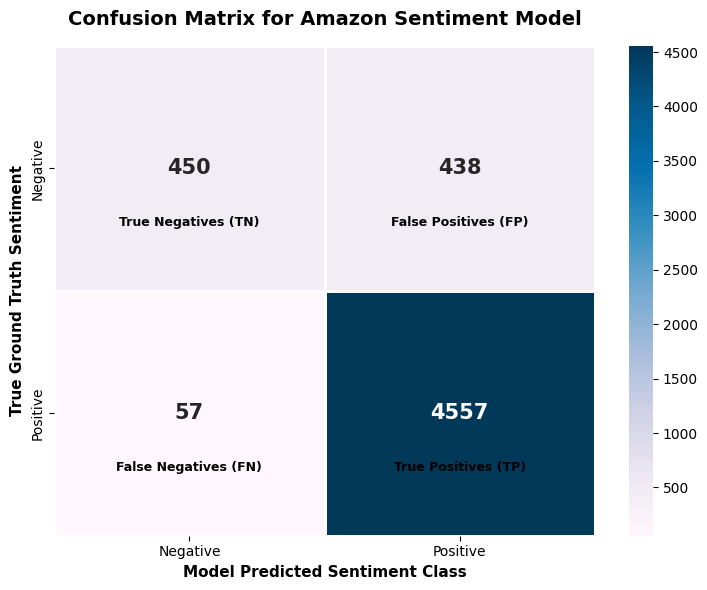

In [11]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot standalone confusion matrix
plt.figure(figsize=(7.5, 6))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='PuBu',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    cbar=True,
    linewidths=2,
    linecolor='white',
    annot_kws={"size": 15, "weight": "bold"}
)

plt.title("Confusion Matrix for Amazon Sentiment Model", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("True Ground Truth Sentiment", fontsize=11, fontweight='bold')
plt.xlabel("Model Predicted Sentiment Class", fontsize=11, fontweight='bold')

# Quadrant Text Overlays
labels = [
    ['True Negatives (TN)', 'False Positives (FP)'],
    ['False Negatives (FN)', 'True Positives (TP)']
]

for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.72,
            labels[i][j],
            ha='center', va='center',
            fontsize=9, fontweight='bold'
        )

plt.tight_layout()
plt.show()

## **Step 6: Testing Custom Unseen Review Samples**
Test the trained model against custom food review sentences and visualize prediction confidence probability scores.

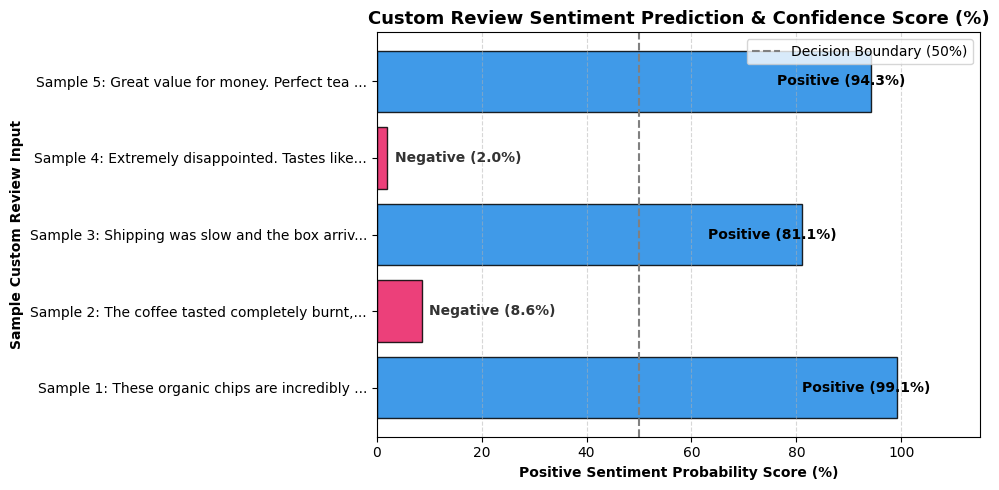

In [12]:
# Custom test reviews
sample_reviews = [
    "These organic chips are incredibly fresh, crispy, and delicious! Will definitely reorder.",
    "The coffee tasted completely burnt, stale, and watered down. Totally awful quality.",
    "Shipping was slow and the box arrived damaged, but the chocolates inside were amazing.",
    "Extremely disappointed. Tastes like pure chemicals and left a terrible aftertaste.",
    "Great value for money. Perfect tea leaves with rich flavor and aroma."
]

# Preprocess and vectorise sample reviews
cleaned_samples = [clean_review_text(rev) for rev in sample_reviews]
samples_tfidf = tfidf.transform(cleaned_samples)

sample_preds = model.predict(samples_tfidf)
sample_probs = model.predict_proba(samples_tfidf)

# (Visualize) Custom Review Sentiment Confidence Probability Plot
fig, ax = plt.subplots(figsize=(10, 5))

short_labels = [f"Sample {i+1}: {rev[:35]}..." for i, rev in enumerate(sample_reviews)]
pos_confidences = sample_probs[:, 1] * 100

colors = ['#1E88E5' if p == 1 else '#E91E63' for p in sample_preds]
bars = ax.barh(short_labels, pos_confidences, color=colors, edgecolor='black', alpha=0.85)

# Add decision threshold line at 50%
ax.axvline(50, color='gray', linestyle='--', linewidth=1.5, label='Decision Boundary (50%)')

for bar, pred in zip(bars, sample_preds):
    width = bar.get_width()
    sentiment_str = "Positive" if pred == 1 else "Negative"
    ax.text(width + (1.5 if width < 80 else -18), bar.get_y() + bar.get_height()/2,
            f"{sentiment_str} ({width:.1f}%)", ha='left', va='center', fontweight='bold',
            color='black' if width >= 80 else '#333333')

plt.xlim(0, 115)
plt.title("Custom Review Sentiment Prediction & Confidence Score (%)", fontsize=13, fontweight='bold')
plt.xlabel("Positive Sentiment Probability Score (%)", fontweight='bold')
plt.ylabel("Sample Custom Review Input", fontweight='bold')
plt.legend(frameon=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **Conclusion**
In this practical, a machine learning model for Sentiment Analysis on Amazon Fine Food Reviews was successfully constructed, trained, and evaluated in Google Colab.

The dataset was loaded directly via kagglehub, cleaned, converted into binary targets, and vectorized using TF-IDF.

An L2-regularized Logistic Regression classifier was trained and evaluated on unseen test data.